In [9]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sy
import pandas as pd
from scipy.optimize import minimize

# Introduction to Linear Regression and Linear Programming

**OBJECTIVES**

- Derive ordinary least squares models for data
- Evaluate regression models using mean squared error
- Examine errors and assumptions in least squares models
- Use `scikit-learn` to fit regression models to data
- Set up linear programming problems with constraints using `scipy.optimize`

## Calculus Refresher

An important idea is that of finding a maximum or minimum of a function.  From calculus, we have the tools required.  Specifically, a maximum or minimum value of a function $f$ occurs wherever $f'(x) = 0$ or is underfined.  Consider the function:

$$f(x) = x^2$$

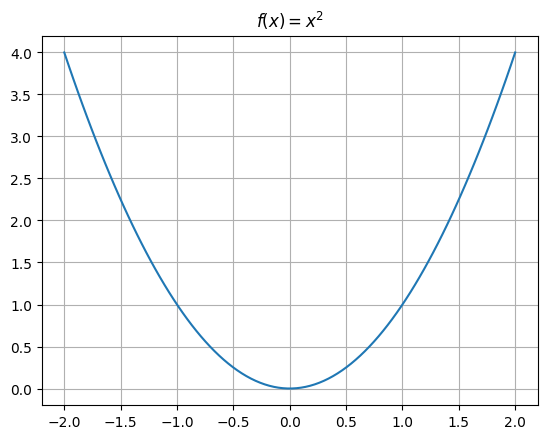

In [10]:
def f(x): return x**2
x = np.linspace(-2, 2, 100)
plt.plot(x, f(x))
plt.grid()
plt.title(r'$f(x) = x^2$');

Here, using our power rule for derivatives of polynomials we have:

$$f'(x) = 2x$$

and are left to solve:

$$0 = 2x$$

or 

$$x = 0$$

**PROBLEM**: Use `minimize` to determine where the function $f(x) = (5 - 2x)^2$ has a minimum.

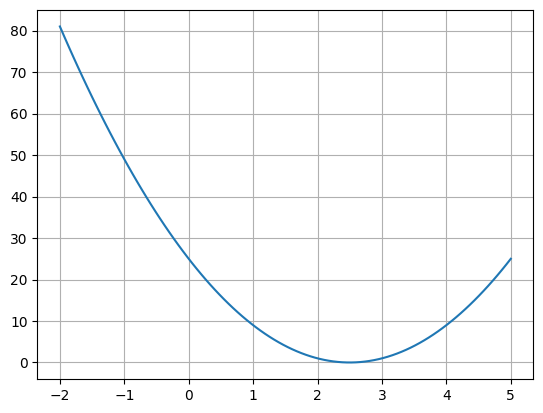

In [11]:
def f(x): return (5 - 2*x)**2
x = np.linspace(-2, 5, 100)
plt.plot(x, f(x))
plt.grid();

In [12]:
# minimize?

In [13]:
x0 = 0
# results = minimize()
# print(results.x)

#### Using the chain rule

**Example 1**: Line of best fit

In [14]:
import seaborn as sns

In [15]:
tips = sns.load_dataset('tips')

In [16]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


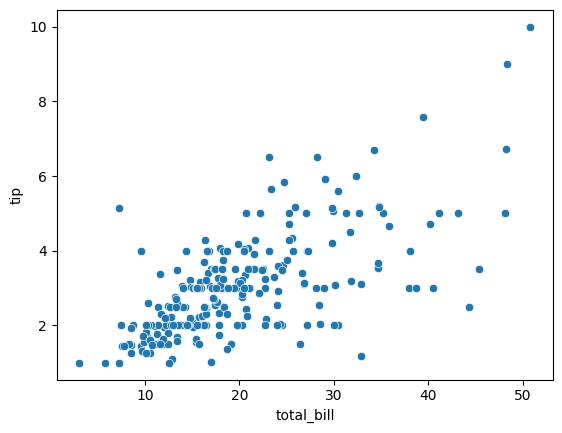

In [17]:
sns.scatterplot(data = tips, x = 'total_bill', y = 'tip');

In [18]:
def y1(x): return .19*x

In [19]:
def y2(x): return .12*x

In [20]:
x = tips['total_bill']

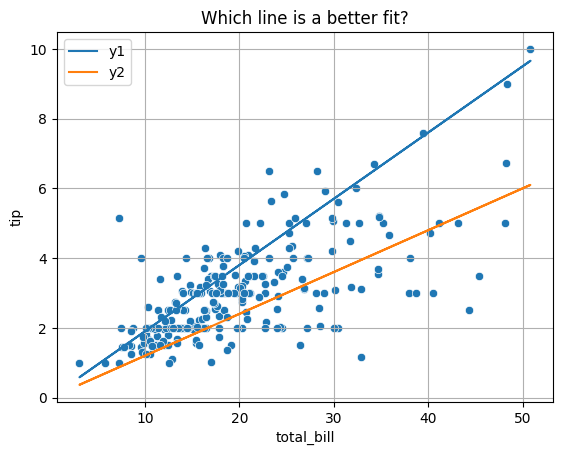

In [21]:
plt.plot(x, y1(x), label = 'y1')
plt.plot(x, y2(x), label = 'y2')
plt.legend()
sns.scatterplot(data = tips, x = 'total_bill', y = 'tip')
plt.title('Which line is a better fit?')
plt.grid();

To decide between all possible lines we will examine the error in all these models and select the one that minimizes this error.

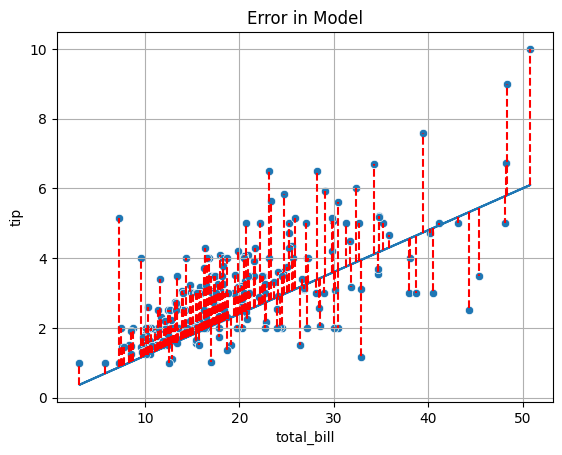

In [22]:
plt.plot(x, y2(x))
for i, yhat in enumerate(y2(x)):
    plt.vlines(x = tips['total_bill'].iloc[i], ymin = yhat, ymax = tips['tip'].iloc[i], color = 'red', linestyle = '--')
sns.scatterplot(data = tips, x = 'total_bill', y = 'tip')
plt.title('Error in Model')
plt.grid();

#### Mean Squared Error

$$\text{MSE}(\beta_0) = \frac{1}{n}\sum_{i = 1}^n (y_i - \beta_0x)^2$$



**OBJECTIVE**: Minimize mean squared error

In [23]:
def mse(beta):
    return np.mean((y - beta*x)**2)

In [24]:
x = tips['total_bill']
y = tips['tip']

In [25]:
mse(.17)

1.502706427336066

In [26]:
for pct in np.linspace(.1, .2, 11):
    print(f'The MSE for slope {pct: .3f} is {mse(pct): .3f}')

The MSE for slope  0.100 is  2.078
The MSE for slope  0.110 is  1.713
The MSE for slope  0.120 is  1.443
The MSE for slope  0.130 is  1.267
The MSE for slope  0.140 is  1.185
The MSE for slope  0.150 is  1.197
The MSE for slope  0.160 is  1.303
The MSE for slope  0.170 is  1.503
The MSE for slope  0.180 is  1.797
The MSE for slope  0.190 is  2.185
The MSE for slope  0.200 is  2.667


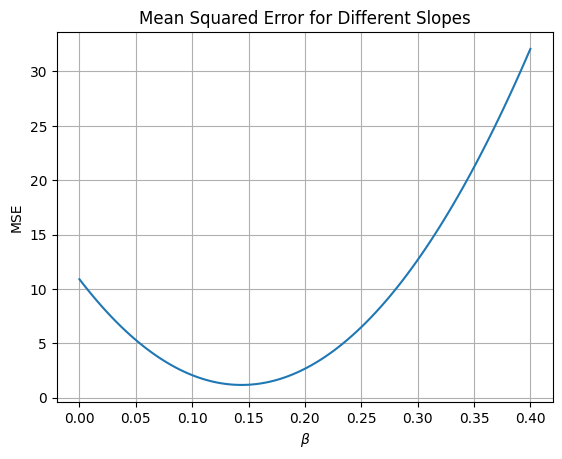

In [27]:
betas = np.linspace(0, .4, 100)
plt.plot(betas, [mse(beta) for beta in betas])
plt.xlabel(r'$\beta$')
plt.ylabel('MSE')
plt.title('Mean Squared Error for Different Slopes')
plt.grid();

#### Using `scipy` 

To find the minimum of our objective function, the `minimize` function from `scipy.optimize` is useful.  This relies on a variety of different optimization algorithms to find the minimum of a function.

In [28]:
from scipy.optimize import minimize

In [29]:
minimize(mse, .1 )

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1.1781161154513358
        x: [ 1.437e-01]
      nit: 1
      jac: [ 1.103e-06]
 hess_inv: [[1]]
     nfev: 6
     njev: 3

### Solving the Problem Exactly

From calculus we know that the minimum value for a quadratic will occur where the first derivative equals zero.  Thus, to determine the equations for the line of best fit, we minimize the MSE function with respect to $\beta$.

$$f(\beta) = \frac{1}{n}\sum_{i = 1}^n (y - \beta x)^2$$

$$f'(\beta) = \frac{-2}{n}\sum_{i = 1}^n(y - \beta x) x$$

$$ 0 = \frac{-2}{n}\sum_{i = 1}^n(y - \beta x) x$$

$$0 = \sum_{i = 1}^n(y - \beta x) x$$

$$0 = \sum yx - \sum \beta x^2 $$

$$\sum \beta x^2 = \sum y x$$

$$\beta \sum x^2 = \sum y x$$

$$\beta = \frac{\sum y x}{\sum x^2}$$

In [30]:
np.sum(tips['total_bill']*tips['tip'])/np.sum(tips['total_bill']**2)

0.14373189527721666

### Adding an intercept

Consider the model:

$$y = \beta_0 + \beta_1 x + \epsilon$$

where $\epsilon = N(0, 1)$.

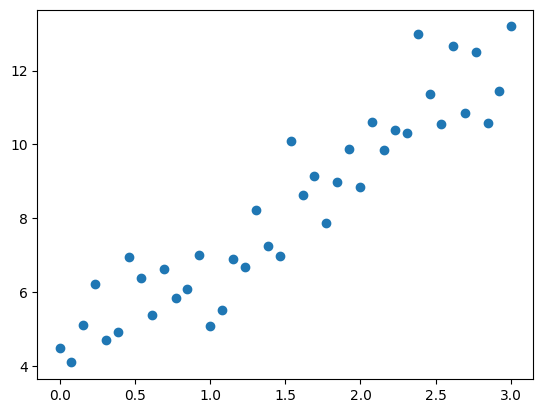

In [31]:
np.random.seed(42)
x = np.linspace(0, 3, 40)
y = 3*x + 4 + np.random.normal(size = len(x))
plt.scatter(x, y)

Now, the objective function changes to be a function in 3-Dimensions where the slope and intercept terms are input and mean squared error is the output.

$$\text{MSE}(\beta_0, \beta_1) = \frac{1}{n}\sum_{i = 1}^n (y - (\beta_0 + \beta_1 x)^2)$$

In [32]:
def mse(betas):
    return np.mean((y - (betas[0] + betas[1]*x))**2)

In [33]:
mse([4, 3])

0.9329508980248764

In [34]:
minimize(mse, [0, 0])

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.829630503231984
        x: [ 4.179e+00  2.735e+00]
      nit: 7
      jac: [ 9.686e-08 -2.235e-08]
 hess_inv: [[ 1.921e+00 -9.483e-01]
            [-9.483e-01  6.327e-01]]
     nfev: 24
     njev: 8

In [35]:
betas = minimize(mse, [0, 0]).x

In [36]:
def lobf(x): return betas[0] + betas[1]*x

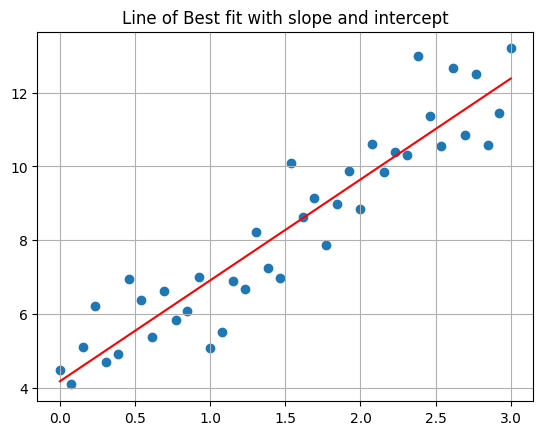

In [37]:
plt.scatter(x, y)
plt.plot(x, lobf(x), color = 'red')
plt.grid()
plt.title('Line of Best fit with slope and intercept');

In [38]:
class LinearReg:
    '''
    This class fits an ordinary lease squares model
    of the form beta_0 + beta_1 * x.
    '''
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None
        
    def mse(self, betas):
        return np.mean((y - (betas[0] + betas[1]*x))**2)
        
    def fit(self, x, y):
        #betas that minimize
        betas = minimize(self.mse, [0, 0]).x
        #set coef_
        self.coef_ = betas[1]
        #set intercept_
        self.intercept_ = betas[0]
        
    
    def predict(self, x):
        return self.intercept_ + self.coef_*x
    
    

In [39]:
x = tips['total_bill']
y = tips['tip']

In [40]:
#instantiate the model
model = LinearReg()

In [41]:
#fit the model on data
model.fit(x, y)

In [42]:
#make predictions on all data
model.predict(x)

0      2.704636
1      2.006223
2      3.126835
3      3.407250
4      3.502822
         ...   
239    3.969131
240    3.774836
241    3.301175
242    2.791807
243    2.892630
Name: total_bill, Length: 244, dtype: float64

In [43]:
model.coef_

0.10502447914641161

In [44]:
model.intercept_

0.9202703450693733

#### A second example

In [45]:
import statsmodels.api as sm
duncan_prestige = sm.datasets.get_rdataset("Duncan", "carData")
print(duncan_prestige.__doc__)

.. container::

   .. container::

      ====== ===============
      Duncan R Documentation
      ====== ===============

      .. rubric:: Duncan's Occupational Prestige Data
         :name: duncans-occupational-prestige-data

      .. rubric:: Description
         :name: description

      The ``Duncan`` data frame has 45 rows and 4 columns. Data on the
      prestige and other characteristics of 45 U. S. occupations in
      1950.

      .. rubric:: Usage
         :name: usage

      .. code:: R

         Duncan

      .. rubric:: Format
         :name: format

      This data frame contains the following columns:

      type
         Type of occupation. A factor with the following levels:
         ``prof``, professional and managerial; ``wc``, white-collar;
         ``bc``, blue-collar.

      income
         Percentage of occupational incumbents in the 1950 US Census who
         earned $3,500 or more per year (about $36,000 in 2017 US
         dollars).

      education
        

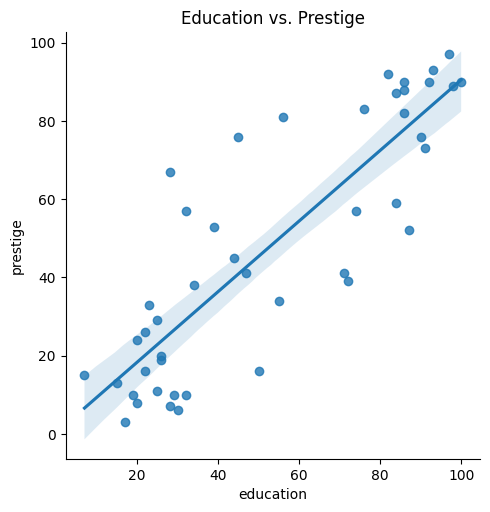

In [46]:
sns.lmplot(duncan_prestige.data, x = 'education', y = 'prestige')
plt.title('Education vs. Prestige');

- Fit a model with an intercept to the data.  
- What is the slope of the line and what does this mean in terms of education and income?
- What is the intercept of the model and what does this mean in terms of education and income?

In [47]:
x = duncan_prestige.data[['education']]
y = duncan_prestige.data['prestige']

In [48]:
x.shape

(45, 1)

In [49]:
# !pip install -U scikit-learn

In [50]:
from sklearn.linear_model import LinearRegression

In [51]:
model = LinearRegression() #instantiate -- step 1

In [52]:
model.fit(x, y)

LinearRegression()

In [53]:
predictions = model.predict(x)
predictions

array([77.85563665, 68.83567885, 83.26761134, 81.46361978, 77.85563665,
       76.05164509, 84.16960712, 90.48357758, 78.75763243, 77.85563665,
       67.03168729, 88.67958602, 87.77759024, 76.05164509, 82.36561556,
       30.95185608, 40.87380966, 50.79576324, 39.97181388, 74.24765353,
       65.22769573, 49.89376746, 64.32569995, 45.38378856, 21.02990249,
       35.46183498, 25.53988139, 29.14786452, 20.12790671, 22.83389405,
       26.44187717,  6.59797001, 23.73588983, 17.42191937, 13.81393625,
       18.32391515, 23.73588983, 25.53988139, 15.61792781, 20.12790671,
       27.34387295, 22.83389405, 18.32391515, 42.67780122, 29.14786452])

In [54]:
model.coef_, model.intercept_

(array([0.90199578]), 0.2839995438216505)

In [55]:
model.coef_[0]

0.9019957803501166

#### Examining Errors in the Model

Once we have a model, it is important to examine the properties of the residuals.  Specifically, we aim to examine the residuals for patterns in error and the overall distribution of these errors.

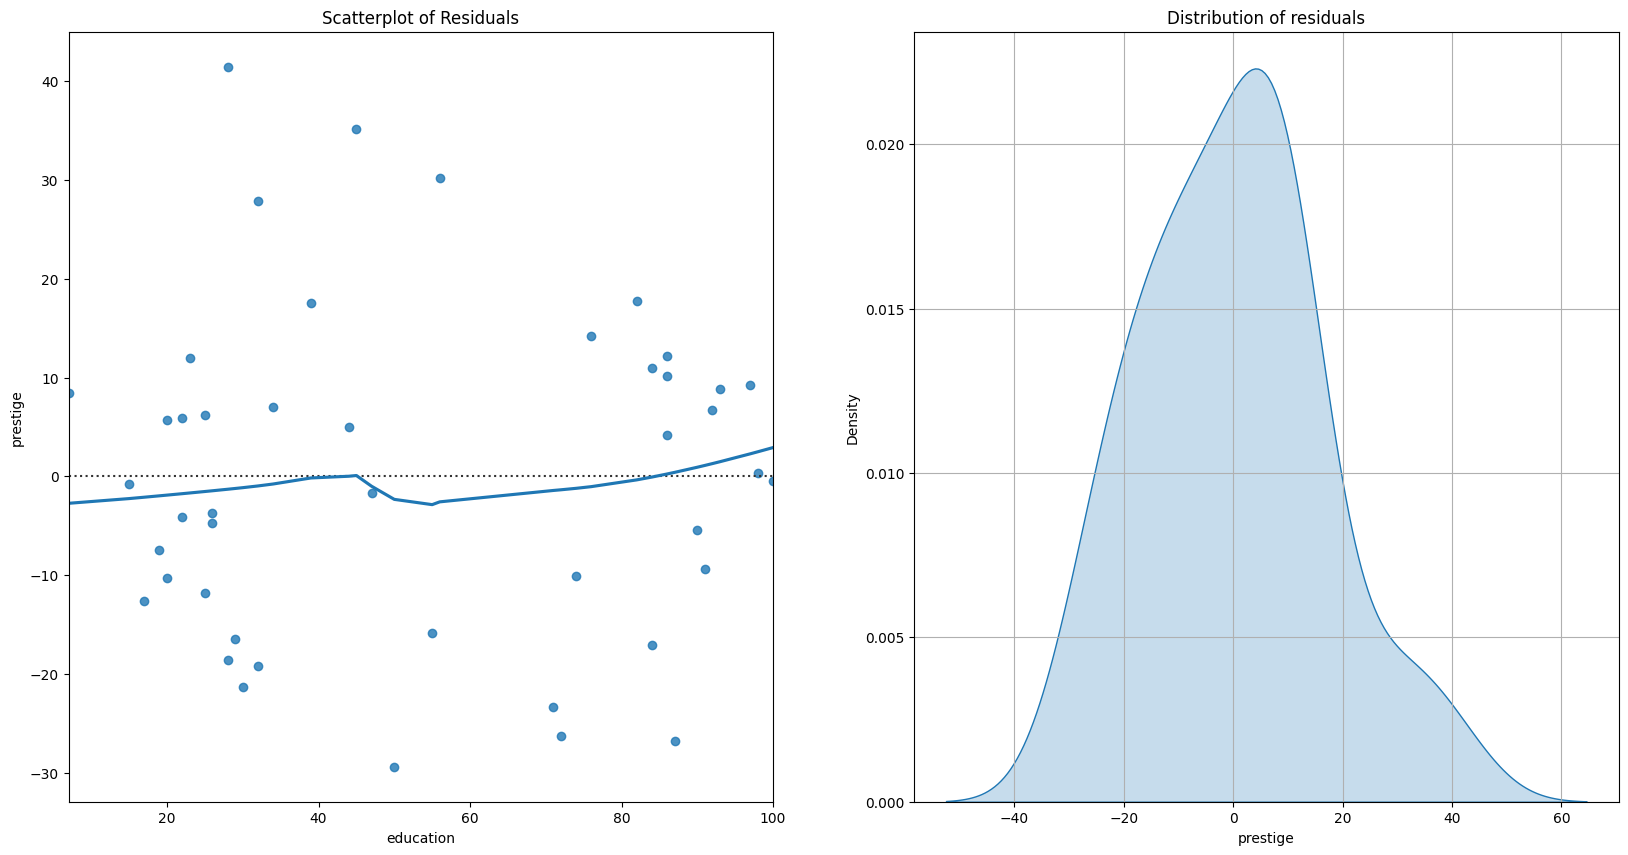

In [56]:
fig, ax = plt.subplots(1, 2, figsize = (20, 10))
sns.residplot(x = x, y = y, ax = ax[0], lowess=True)
ax[0].set_title('Scatterplot of Residuals')
sns.kdeplot((y - (model.intercept_ + model.coef_[0]*x.values[:, 0])), ax = ax[1], fill = True);
ax[1].grid()
ax[1].set_title('Distribution of residuals');

### Using `scikit-learn`

The `scikit-learn` library has many predictive models and modeling tools.  It is a popular library in industry for Machine Learning tasks. [docs](https://scikit-learn.org/stable/index.html)

In [57]:
# !pip install -U scikit-learn

In [58]:
credit = pd.read_csv('data/Credit.csv', index_col=0)
credit.head()

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
1,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
2,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
3,104.593,7075,514,4,71,11,Male,No,No,Asian,580
4,148.924,9504,681,3,36,11,Female,No,No,Asian,964
5,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


In [59]:
from sklearn.linear_model import LinearRegression

**PROBLEM**: Which feature is the strongest predictor of `Balance` in the data?

<Axes: >

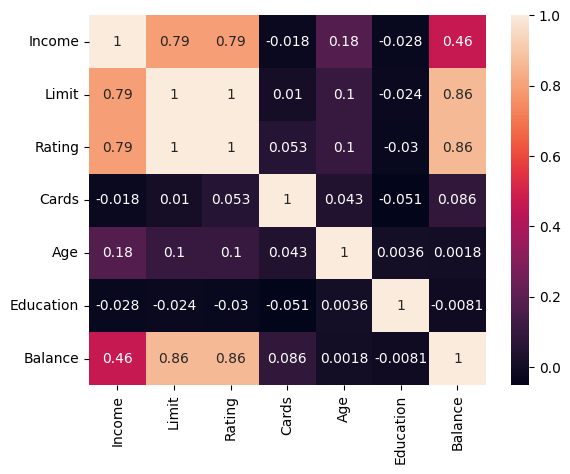

In [60]:
sns.heatmap(credit.corr(numeric_only = True), annot = True)

In [67]:
X = credit[['Rating']]
y = credit['Balance']

**PROBLEM**: Build a `LinearRegression` model, determine the **Root Mean Squared Error** and interpret the slope and intercept.

1. Instantiate
2. Fit
3. Predict/score

In [68]:
credit_model = LinearRegression()

In [69]:
credit_model.fit(X, y)

LinearRegression()

In [70]:
yhat = credit_model.predict(X)

In [71]:
print(f'The model is y = {credit_model.coef_[0]}x + {credit_model.intercept_}')

The model is y = 2.5662403273433196x + -390.84634178723786


(array([  3.,  11.,  31.,  91., 116.,  86.,  41.,   9.,   6.,   6.]),
 array([-712.2825064 , -558.1506416 , -404.01877679, -249.88691199,
         -95.75504718,   58.37681762,  212.50868243,  366.64054724,
         520.77241204,  674.90427685,  829.03614165]),
 <BarContainer object of 10 artists>)

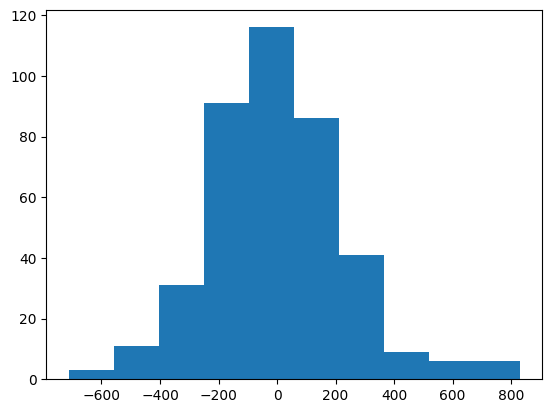

In [74]:
plt.hist(y - yhat)

In [102]:
from sklearn.metrics import mean_squared_error

In [103]:
#error between true and predicted


### Problem: Determine $\alpha$ and $\beta$ of an investment

Consider an investment with return of the market as $R_M$ (say the S&P) and the return of a stock $R$ over the same time period.

$$R = \alpha + \beta*R_M + \epsilon$$

In [96]:
import yfinance as yf

In [97]:
data = yf.download(["NVDA", "SPY"], period="5y")
data.head()

Failed to get ticker 'SPY' reason: Expecting value: line 1 column 1 (char 0)
Failed to get ticker 'NVDA' reason: Expecting value: line 1 column 1 (char 0)
[*********************100%***********************]  2 of 2 completed

2 Failed downloads:
['SPY', 'NVDA']: AttributeError("'str' object has no attribute 'get'")


Empty DataFrame
Columns: [(Adj Close, NVDA), (Adj Close, SPY), (Close, NVDA), (Close, SPY), (High, NVDA), (High, SPY), (Low, NVDA), (Low, SPY), (Open, NVDA), (Open, SPY), (Volume, NVDA), (Volume, SPY)]
Index: []

In [98]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 0 entries
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, NVDA)  0 non-null      float64
 1   (Adj Close, SPY)   0 non-null      float64
 2   (Close, NVDA)      0 non-null      float64
 3   (Close, SPY)       0 non-null      float64
 4   (High, NVDA)       0 non-null      float64
 5   (High, SPY)        0 non-null      float64
 6   (Low, NVDA)        0 non-null      float64
 7   (Low, SPY)         0 non-null      float64
 8   (Open, NVDA)       0 non-null      float64
 9   (Open, SPY)        0 non-null      float64
 10  (Volume, NVDA)     0 non-null      float64
 11  (Volume, SPY)      0 non-null      float64
dtypes: float64(12)
memory usage: 0.0 bytes


In [99]:
close = data.iloc[:, [0, 1]]

<Axes: xlabel='Date'>

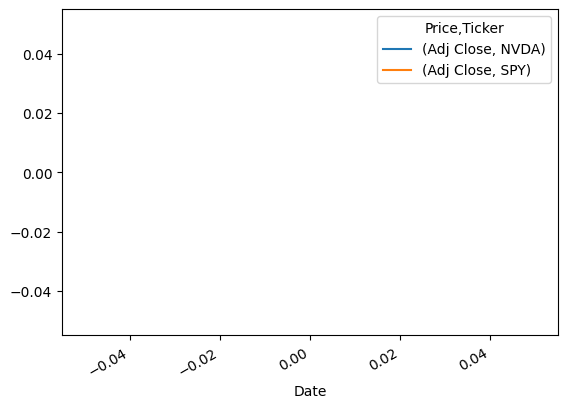

In [100]:
close.pct_change().plot()

In [105]:
returns = close.pct_change()

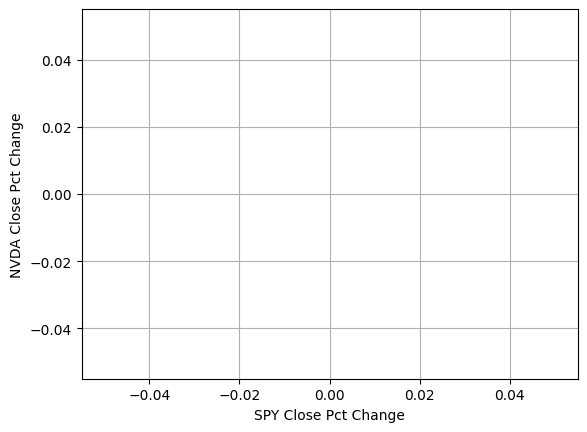

In [106]:
sns.regplot(x = returns.iloc[:, 1], y = returns.iloc[:, 0], scatter_kws={'alpha': 0.3})
plt.xlabel('SPY Close Pct Change')
plt.ylabel('NVDA Close Pct Change')
plt.grid();

In [107]:
#instantiate


In [108]:
#fit


In [109]:
#examine our alpha and beta
